In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Clean_Dataset.csv")
print(df)

        Unnamed: 0   airline   flight source_city departure_time stops  \
0                0  SpiceJet  SG-8709       Delhi        Evening  zero   
1                1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2                2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3                3   Vistara   UK-995       Delhi        Morning  zero   
4                4   Vistara   UK-963       Delhi        Morning  zero   
...            ...       ...      ...         ...            ...   ...   
300148      300148   Vistara   UK-822     Chennai        Morning   one   
300149      300149   Vistara   UK-826     Chennai      Afternoon   one   
300150      300150   Vistara   UK-832     Chennai  Early_Morning   one   
300151      300151   Vistara   UK-828     Chennai  Early_Morning   one   
300152      300152   Vistara   UK-822     Chennai        Morning   one   

         arrival_time destination_city     class  duration  days_left  price  
0               Night           

In [5]:
df.dropna(inplace= True)
df.drop_duplicates(inplace = True)

Q1 Total airline 6


Q2 Total Flights 300153


Q3 Economy and Business classes are : class
Economy     206666
Business     93487
Name: count, dtype: int64


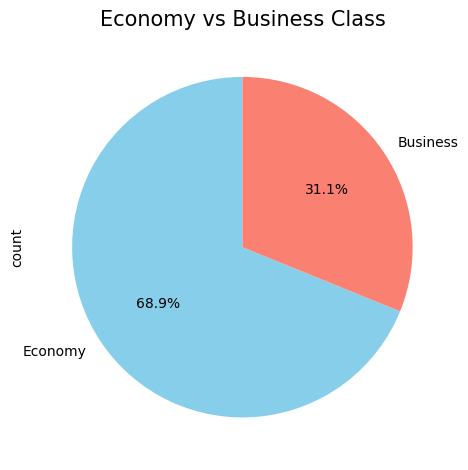



Q4 Maximum price is : 123071 $


Miniimum price is : 1105 $


Average price is : 20889.660523133203 $


 Airline with Most Flights:  Vistara No of Flights:  127859


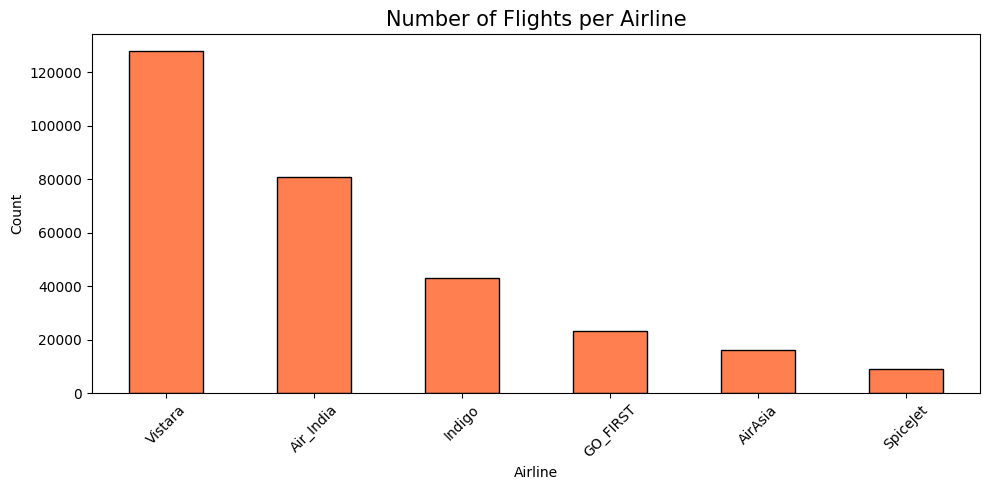



Type od stops:  ['zero' 'one' 'two_or_more']
stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64


In [32]:
total_airline = df["airline"].nunique()
print("Q1 Total airline",total_airline)

print("\n")

total_flight =df["flight"].value_counts().sum()
print("Q2 Total Flights",total_flight)

print("\n")

economy = df["class"].value_counts()
print("Q3 Economy and Business classes are :",economy)
economy.plot(kind="pie",
        autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)
plt.title('Economy vs Business Class', fontsize=15)
plt.tight_layout()
plt.show()

print("\n")

max_price= df["price"].max()
print("Q4 Maximum price is :", max_price,"$")

print("\n")

min_price = df["price"].min()
print("Miniimum price is :", min_price,"$")

print("\n")

avg_price = df["price"].mean()
print("Average price is :",avg_price,"$")

print("\n")

most_flight =df["airline"].value_counts().idxmax()
more_flights = df["airline"].value_counts().max()
print(" Airline with Most Flights: ",most_flight,"No of Flights: ",more_flights)
plt.figure(figsize=(10,5))
df['airline'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Number of Flights per Airline', fontsize=15)
plt.xlabel('Airline')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("\n")


stop_type = df["stops"].unique()
stop_count = df["stops"].value_counts()
print("Type od stops: ",stop_type)
print(stop_count)

Q1. AirAsia  airline is the cheapest on average
Q1. The amount is : 4091.0727419555224 $


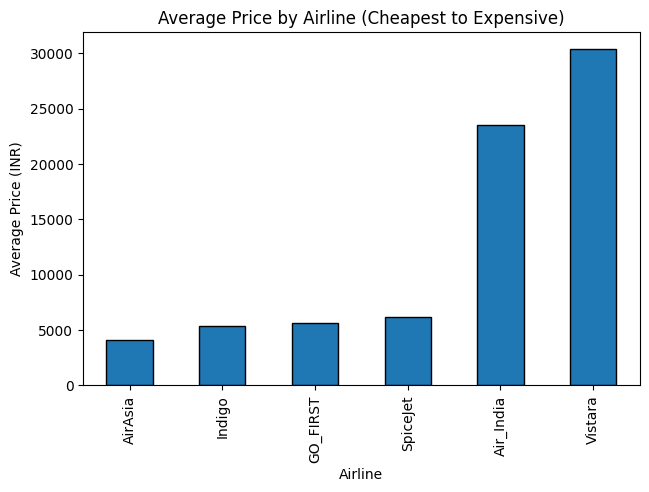



Q2. Vistara  is the most expensive on average
Q2. The amouunt is : 30396.53630170735


Q3. Delhi  source city has the most flights
Q3. No of flight :  61343


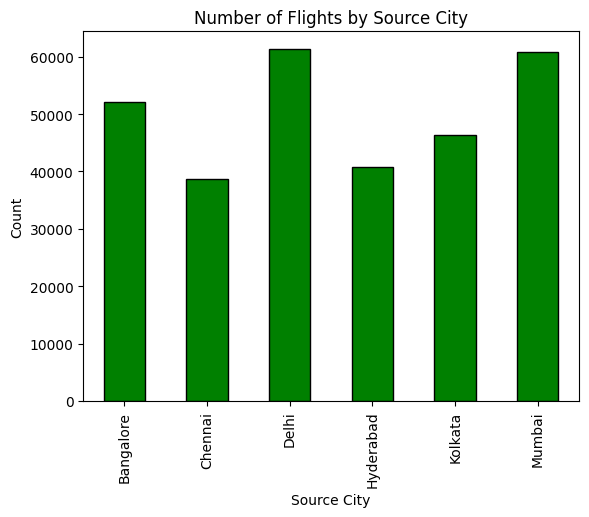



Q4. Most popular destinatio city is   Mumbai


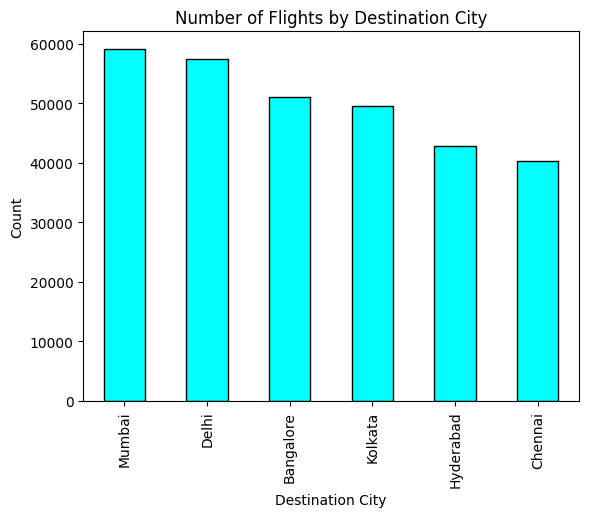



Q5. Late_Night slot has the cheapest flights


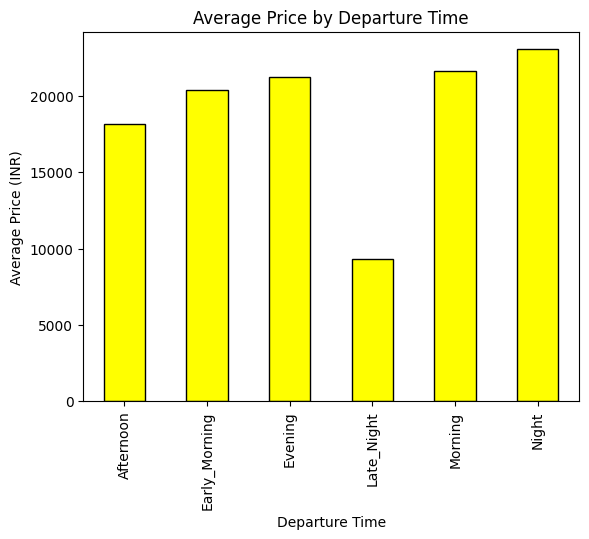



stops
one            22900.992482
two_or_more    14113.450775
zero            9375.938535
Name: price, dtype: float64


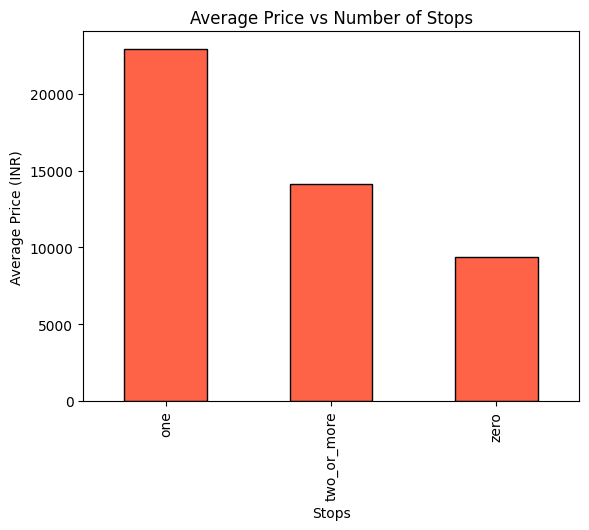

days_left
1     21591.867151
2     30211.299801
3     28976.083569
4     25730.905653
5     26679.773368
6     24856.493902
7     25588.367351
8     24895.883995
9     25726.246072
10    25572.819134
Name: price, dtype: float64


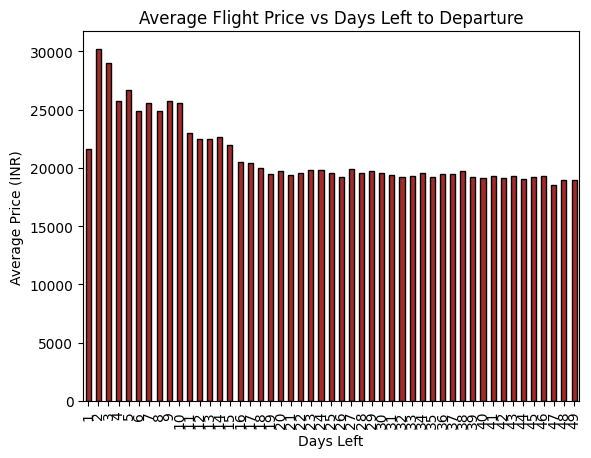

route
Chennai->Bangalore    25081.850454
Kolkata->Chennai      23660.361040
Bangalore->Kolkata    23500.061229
Bangalore->Chennai    23321.850078
Mumbai->Bangalore     23147.873807
Name: price, dtype: float64
route
Mumbai->Delhi       18725.320008
Delhi->Bangalore    17880.216315
Bangalore->Delhi    17723.313972
Delhi->Hyderabad    17347.288379
Hyderabad->Delhi    17243.945685
Name: price, dtype: float64


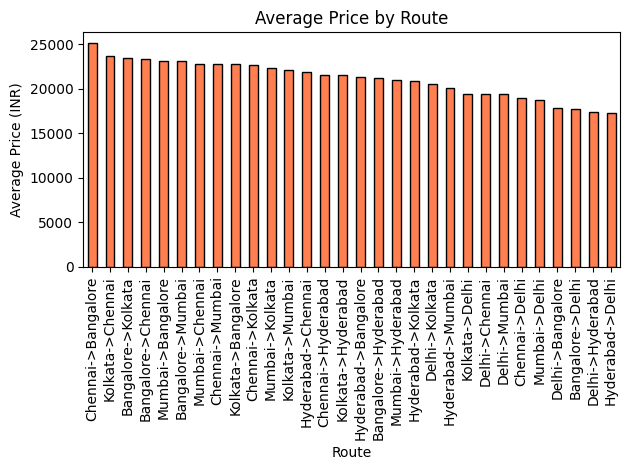

In [6]:
group = df.groupby("airline")
a  = group["price"].mean().sort_values()
avg_air_name = a.idxmin()
avg_air_price = a.min()
print("Q1.",avg_air_name," airline is the cheapest on average")
print("Q1. The amount is :",avg_air_price,"$")
a.plot(kind="bar",edgecolor = "black")
plt.tight_layout()
plt.title("Average Price by Airline (Cheapest to Expensive)")
plt.xlabel('Airline')
plt.ylabel('Average Price (INR)')
plt.show()

print("\n")

max_air_name = a.idxmax()
max_air_price = a.max()
print("Q2.",max_air_name," is the most expensive on average")
print("Q2. The amouunt is :",max_air_price)


print("\n")

group1 = df.groupby("source_city")
b = group1["flight"].count()
most_city_name = b.idxmax()
most_city_flight = b.max()
print("Q3.",most_city_name," source city has the most flights")
print("Q3. No of flight : ",most_city_flight)
b.plot(kind="bar",edgecolor = "black",color = "green")
plt.title("Number of Flights by Source City")
plt.xlabel('Source City')
plt.ylabel('Count')
plt.show()

print("\n")
c= df["destination_city"].value_counts()
most_popular =c.idxmax()
print("Q4. Most popular destinatio city is  ",most_popular)
c.plot(kind="bar",color= "cyan",edgecolor = "black")
plt.title('Number of Flights by Destination City')
plt.xlabel('Destination City')
plt.ylabel('Count')
plt.show()


print("\n")

group2 = df.groupby("departure_time")
d = group2["price"].mean()
departure_min= d.idxmin()
print("Q5.",departure_min,"slot has the cheapest flights")
d.plot(kind="bar",color= "yellow",edgecolor = "black")
plt.title('Average Price by Departure Time')
plt.xlabel('Departure Time')
plt.ylabel('Average Price (INR)')

plt.show()

print("\n")

group3 = df.groupby("stops")
stops_avg_price = group3["price"].mean().sort_values(ascending=False)
print(stops_avg_price)
stops_avg_price.plot(kind="bar",color= "tomato",edgecolor = "black")
plt.title("Average Price vs Number of Stops")
plt.xlabel('Stops')
plt.ylabel('Average Price (INR)')
plt.show()

group4 = df.groupby("days_left")
days_avg_price= group4["price"].mean()
print(days_avg_price.head(10))
days_avg_price.plot(kind="bar",color="brown",edgecolor = "black")
plt.title('Average Flight Price vs Days Left to Departure')
plt.xlabel('Days Left')
plt.ylabel('Average Price (INR)')
plt.show()


df["route"]=df["source_city"]+"->"+ df["destination_city"]
group5 = df.groupby("route")
route_avg_price= group5["price"].mean().sort_values(ascending=False)
print(route_avg_price.head(5))
print(route_avg_price.tail(5))

route_avg_price.plot(kind="bar",color = "coral",edgecolor = "black")
plt.title('Average Price by Route',)
plt.xlabel('Route')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



Q15. Best value airline:  AirAsia
Q15. Worst value airline:  Vistara


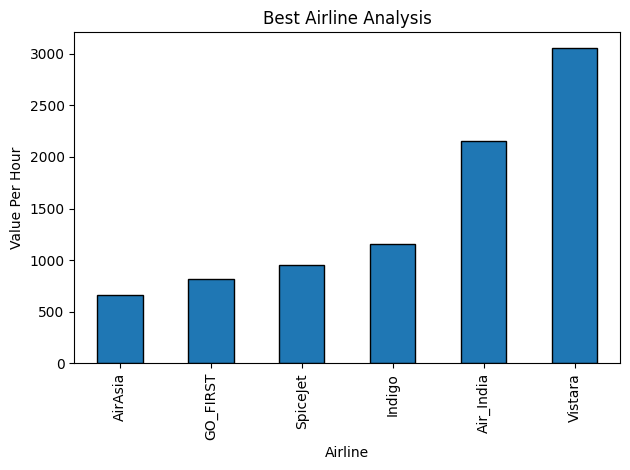



Q16. For same route the cheapest airline is:  AirAsia


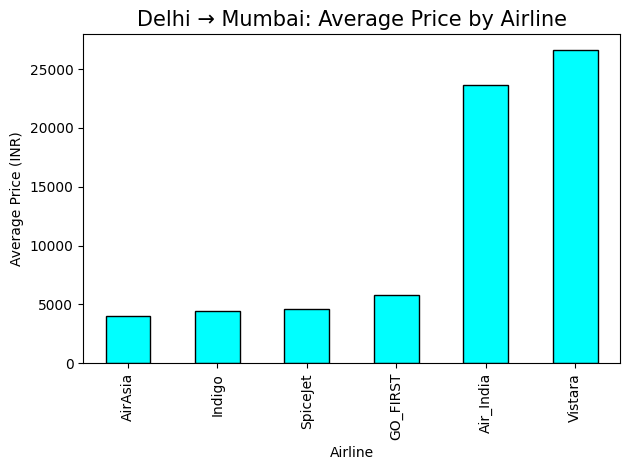

                    route   airline        price
0      Bangalore->Chennai   AirAsia  2073.043478
6        Bangalore->Delhi   AirAsia  4807.092426
12   Bangalore->Hyderabad   AirAsia  2931.494792
18     Bangalore->Kolkata   AirAsia  4443.468160
24      Bangalore->Mumbai   AirAsia  3342.385350
30     Chennai->Bangalore   AirAsia  1914.760870
36         Chennai->Delhi   AirAsia  3697.314003
44     Chennai->Hyderabad  GO_FIRST  1613.105263
48       Chennai->Kolkata   AirAsia  3682.338762
54        Chennai->Mumbai   AirAsia  2691.100000
60       Delhi->Bangalore   AirAsia  5316.400904
66         Delhi->Chennai   AirAsia  3393.982955
72       Delhi->Hyderabad   AirAsia  4733.344780
78         Delhi->Kolkata   AirAsia  4160.479328
84          Delhi->Mumbai   AirAsia  3981.191456
90   Hyderabad->Bangalore   AirAsia  3135.866460
97     Hyderabad->Chennai  GO_FIRST  1942.263158
101      Hyderabad->Delhi   AirAsia  3960.015101
107    Hyderabad->Kolkata   AirAsia  3269.745592
113     Hyderabad->M

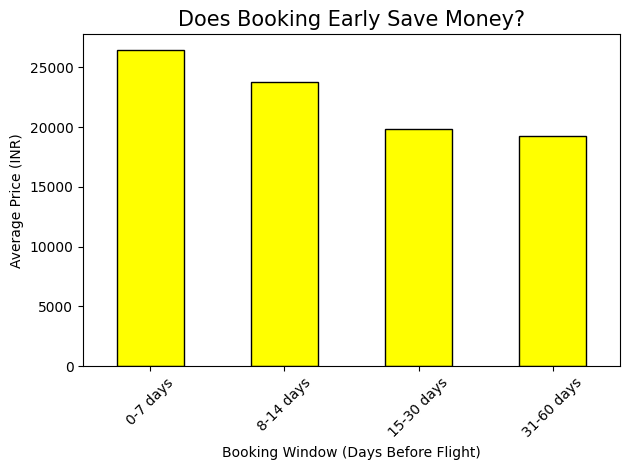



Q18.Top 5 Cheapest Combinations:
  airline stops   class       price
 GO_FIRST  zero Economy 3526.924915
  AirAsia  zero Economy 3747.960970
   Indigo  zero Economy 4023.049037
Air_India  zero Economy 4062.093675
  AirAsia   one Economy 4096.963741


Q18.Top 5 Most Expensive Combinations:
  airline       stops    class        price
  Vistara        zero Business 29281.295232
Air_India         one Business 49311.461068
Air_India two_or_more Business 57383.054795
  Vistara         one Business 57594.844568
  Vistara two_or_more Business 73358.063657


Q18. airline       GO_FIRST
stops             zero
class          Economy
price      3526.924915
Name: 11, dtype: object


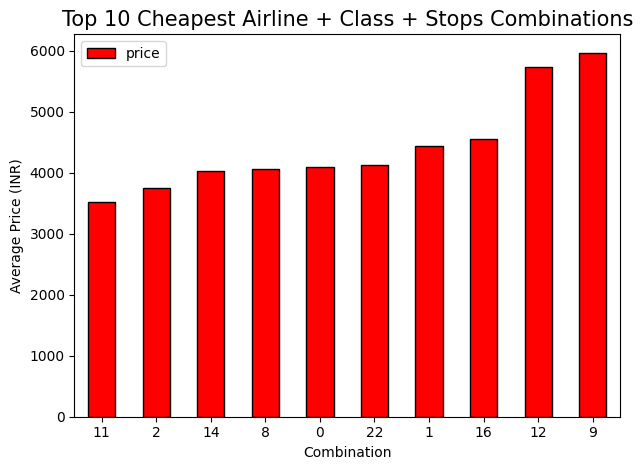



    Q19. Weak Correlation
    Q19. Duration does not strongly affect price


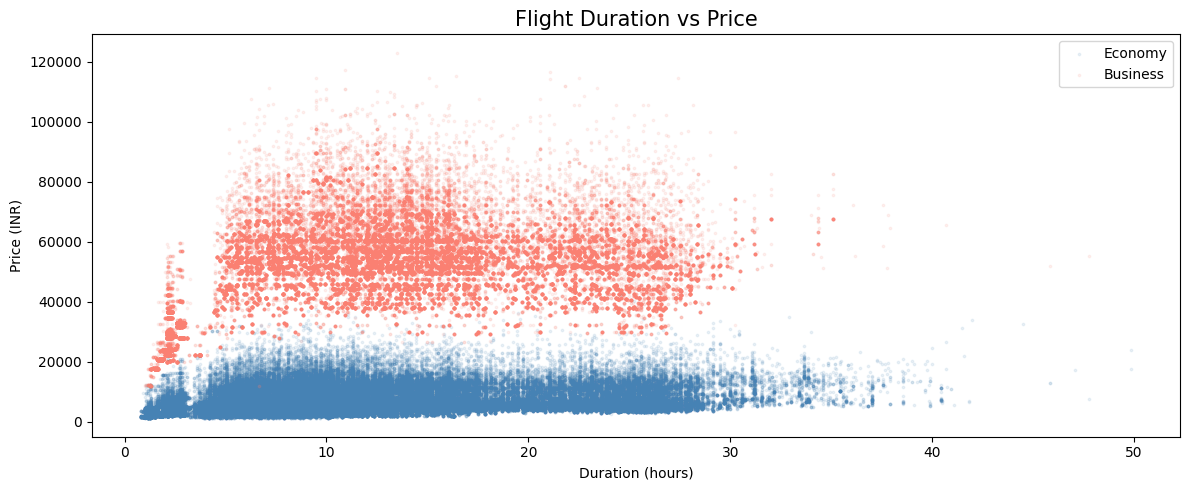



Q20. Cheapest time slot:  Late_Night
Q20. Expensive time slot:  Night


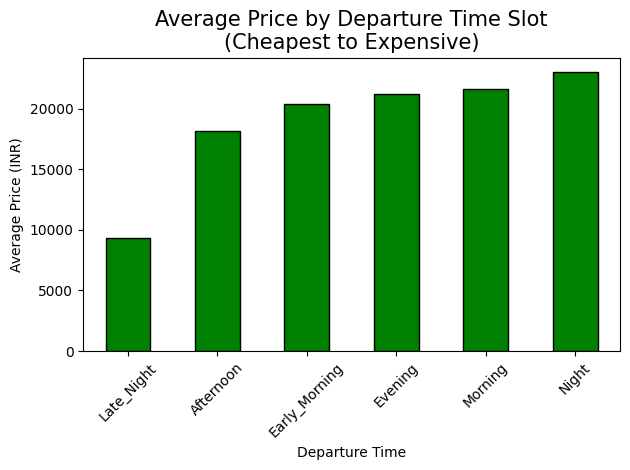

In [24]:
df["price_per_hours"] =df["price"]/df["duration"] 
airline_value = df.groupby("airline")["price_per_hours"].mean().sort_values(ascending=True)
print("Q15. Best value airline: ",airline_value.idxmin())
print("Q15. Worst value airline: ",airline_value.idxmax())
airline_value.plot(kind="bar",edgecolor= "black")
plt.title("Best Airline Analysis")
plt.xlabel("Airline")
plt.ylabel("Value Per Hour")
plt.tight_layout()
plt.show()

print("\n")

route_df= df[(df["source_city"]== "Delhi")&
             (df["destination_city"]=="Mumbai")]
route_airline_price = route_df.groupby("airline")["price"].mean().sort_values(ascending=True)
print("Q16. For same route the cheapest airline is: ",route_airline_price.idxmin())
route_airline_price.plot(kind="bar",color= "cyan",edgecolor = "black")
plt.title('Delhi → Mumbai: Average Price by Airline', fontsize=15)
plt.xlabel('Airline')
plt.ylabel('Average Price (INR)')
plt.tight_layout()
plt.show()
# for all route
all_route= df.groupby(["route","airline"])["price"].mean().reset_index()
cheapest_route = all_route.loc[all_route.groupby("route")["price"].idxmin()]
print(cheapest_route)

print("\n")

df["booking_window"] = pd.cut(df["days_left"],
                              bins=[0, 7, 14, 30, 60, 100],
                              labels=['0-7 days', '8-14 days', 
                                       '15-30 days', '31-60 days', 
                                       '61-100 days'])

booking_price = df.groupby("booking_window",observed=True)["price"].mean().sort_index()
# print(booking_price)
if booking_price.iloc[-1]<booking_price.iloc[0]:
    print("Q17. Yes early booking is always cheaper")
else:
    print("Q17. No early booking is not cheaper")

print("\n")
booking_price.plot(kind="bar",color = "yellow",edgecolor= "black")
plt.title('Does Booking Early Save Money?', fontsize=15)
plt.xlabel('Booking Window (Days Before Flight)')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("\n")

combo= df.groupby(["airline","stops","class"])["price"].mean().reset_index().sort_values("price")
print('Q18.Top 5 Cheapest Combinations:')
print(combo.head(5).to_string(index=False))
print("\n")
print('Q18.Top 5 Most Expensive Combinations:')
print(combo.tail(5).to_string(index=False))
print("\n")
cheapest = combo.iloc[0]
print("Q18.",cheapest)
combo.head(10).plot(kind="bar",color= "red",edgecolor= "black")
plt.title('Top 10 Cheapest Airline + Class + Stops Combinations', fontsize=15)
plt.xlabel('Combination')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=360)
plt.tight_layout()
plt.show()

print("\n")

correlation= df["duration"].corr(df["price"])
if correlation >0.5:
    print('    Q19.  Strong Positive Correlation!')
    print('    Q19. Longer flights = Higher price')
elif correlation>0.3:
    print('     Q19. Moderate Positive Correlation')
    print('     Q19. Duration somewhat affects price')
else:
    print('    Q19. Weak Correlation')
    print('    Q19. Duration does not strongly affect price')

economy = df[df["class"]=="Economy"]
business = df[df["class"]=="Business"]
plt.figure(figsize=(12,5))
plt.scatter(economy["duration"],economy["price"],
            alpha=0.1, color='steelblue', s=3, label='Economy')
plt.scatter(business["duration"],business["price"],
            alpha=0.1, color='salmon', s=3, label='Business')
plt.title('Flight Duration vs Price', fontsize=15)
plt.xlabel('Duration (hours)')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n")

cheapest_slot= df.groupby("departure_time")["price"].mean().sort_values()
print("Q20. Cheapest time slot: ",cheapest_slot.idxmin())
print("Q20. Expensive time slot: ",cheapest_slot.idxmax())
cheapest_slot.plot(kind="bar",color= "green",edgecolor = "black")
plt.title('Average Price by Departure Time Slot\n(Cheapest to Expensive)', fontsize=15)
plt.xlabel('Departure Time')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()